#### FS interneuron model


Autapse predominantly 1) narrows the distribution of ISI values. Neuron firing is restricted to a very small range. 2) Firing frequencies is approximately halved in the presence of an autapse.

In [1]:
import sys
sys.path.append("..\\") # parent directory
from AQUA_general import AQUA
from batchAQUA_general import batchAQUA
from stimulus import *
from plotting_functions import *
from phase_response import *


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

100%|██████████| 199999/199999 [00:02<00:00, 82920.88it/s]


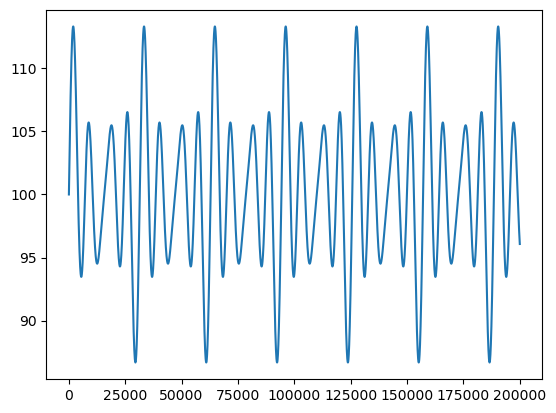

In [ ]:
# regular spiking neuron
FS = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.0, 'f': 0.0, 'tau': 0.0}

FS_a = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.14, 'f': -350.0, 'tau': 2.0}

T = 2  #s
dt = 0.01 # ms
N_iter = int(1000*T/dt)

x_ini = np.array([-80, 0, 0])
t_ini = 0.0

N_neurons = 200
I_range = np.linspace(0, 700, 200)

neuron = AQUA(FS)
neuron.Initialise(x_ini, t_ini)

neuron_aut = AQUA(FS_a)
neuron_aut.Initialise(x_ini, t_ini)


y_0 = 0
delay = 300
I_end = 400
#I_inj = ramp(N_iter, dt, y_0, delay, I_end)


I_h = 650
#I_inj = step_current(N_iter, dt, y_0, delay, I_h)

I_inj = superposed_sinusoid(N_iter, dt) + 75
plt.plot(I_inj)


X, T, spikes = neuron.update_RK2(dt, N_iter, I_inj)
ISI = np.round(np.diff(spikes), decimals = 4)
X2, T, spikes_2 = neuron_aut.update_RK2(dt, N_iter, I_inj)
ISI_2 = np.round(np.diff(spikes_2), decimals = 4)

(200000,)


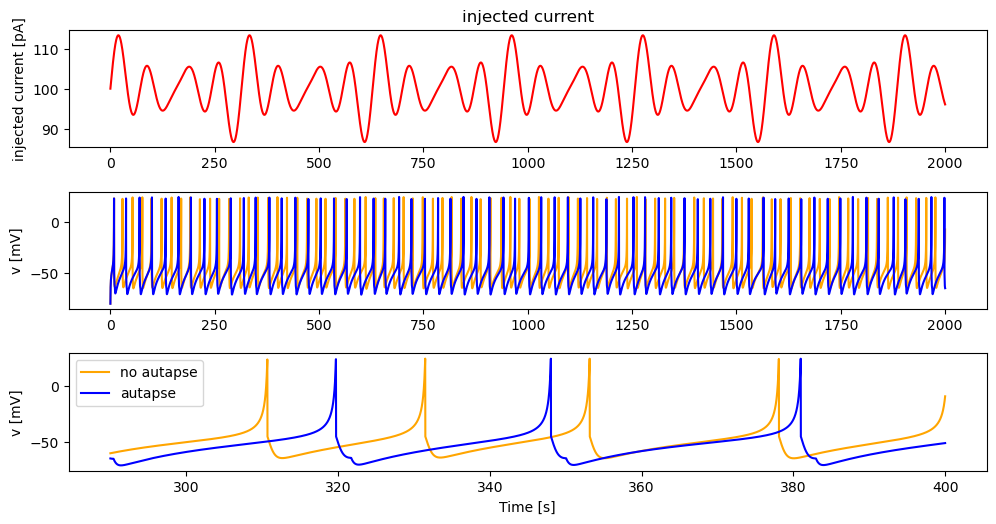

In [3]:
print(np.shape(X[0, :]))
split = np.arange(29000, 40000)
fig, ax = compare_trains(X[0, :], X2[0, :], T, I_inj, indices = split)

plt.show()

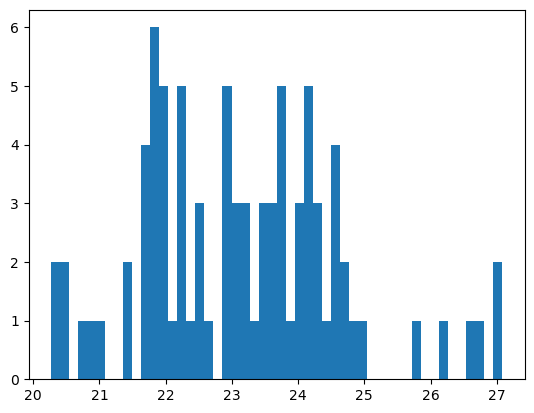

In [4]:
plt.hist(ISI, bins = 50)
plt.show()

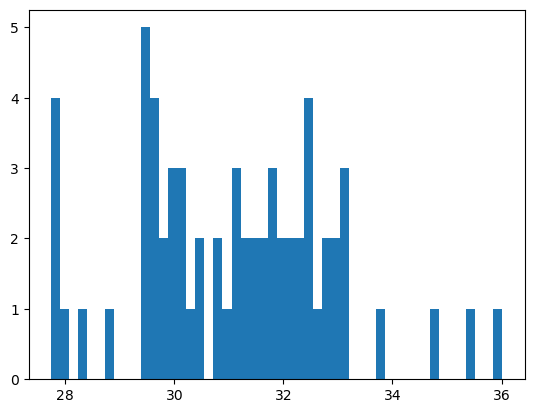

In [5]:
plt.hist(ISI_2, bins = 50)
plt.show()

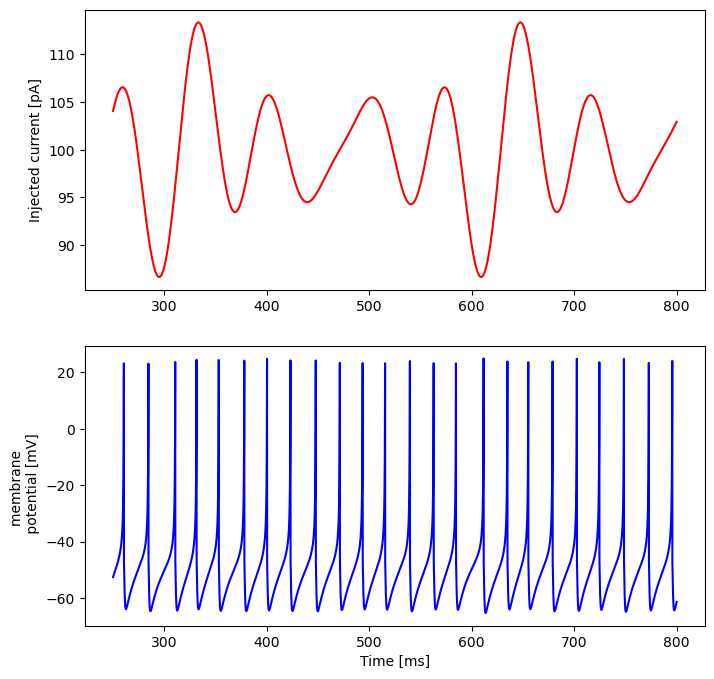

In [6]:
fig, ax = plot_potential_versus_injected(X, T, I_inj, split = np.arange(25000, 80000))
plt.show()

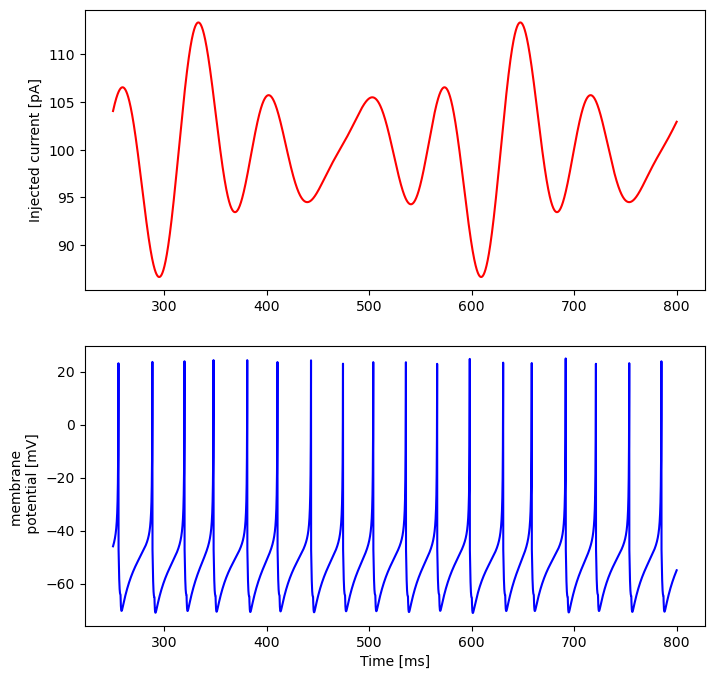

In [7]:
fig, ax = plot_potential_versus_injected(X2, T, I_inj, split = np.arange(25000, 80000))
plt.show()